<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
import pandas as pd
# Step 1: Download the dataset
# !wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey_data.csv")

# Display the first few rows of the data to understand its structure
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


In [3]:
import pandas as pd
import numpy as np

# 1. Define the logical mapping
# We use the midpoint or a rank to turn the string into a plot-able number
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': np.nan  # Use NaN to ignore these in the Scatter Plot
}

# 2. Apply the mapping using the .map() method
# This creates a new numeric column while keeping your original data safe
df['Age_Numeric'] = df['Age'].map(age_mapping)

In [4]:
#Write your code heredf

df['SOPartFreq'].unique()

<StringArray>
[                                                 nan,
                             'Multiple times per day',
                              'Daily or almost daily',
                'Less than once per month or monthly',
                               'A few times per week',
                    'A few times per month or weekly',
 'I have never participated in Q&A on Stack Overflow']
Length: 7, dtype: str

In [5]:
df_clean = df[['Age_Numeric', 'JobSat', 'SOPartFreq']].dropna()

In [6]:
# Group by both axes to get counts for every coordinate
df_bubble = df_clean.groupby(['Age_Numeric', 'SOPartFreq'], as_index=False).count()
df_bubble

,Age_Numeric,SOPartFreq,JobSat
0,15.0,A few times per month or weekly,10
1,15.0,A few times per week,2
2,15.0,Daily or almost daily,3
3,15.0,I have never participated in Q&A on Stack Over...,18
4,15.0,Less than once per month or monthly,25
5,15.0,Multiple times per day,1
6,21.0,A few times per month or weekly,330
7,21.0,A few times per week,127
8,21.0,Daily or almost daily,36
9,21.0,I have never participated in Q&A on Stack Over...,972


In [7]:
df['JobSat'].describe()

count    29131.000000
mean         6.934915
std          2.088356
min          0.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: JobSat, dtype: float64

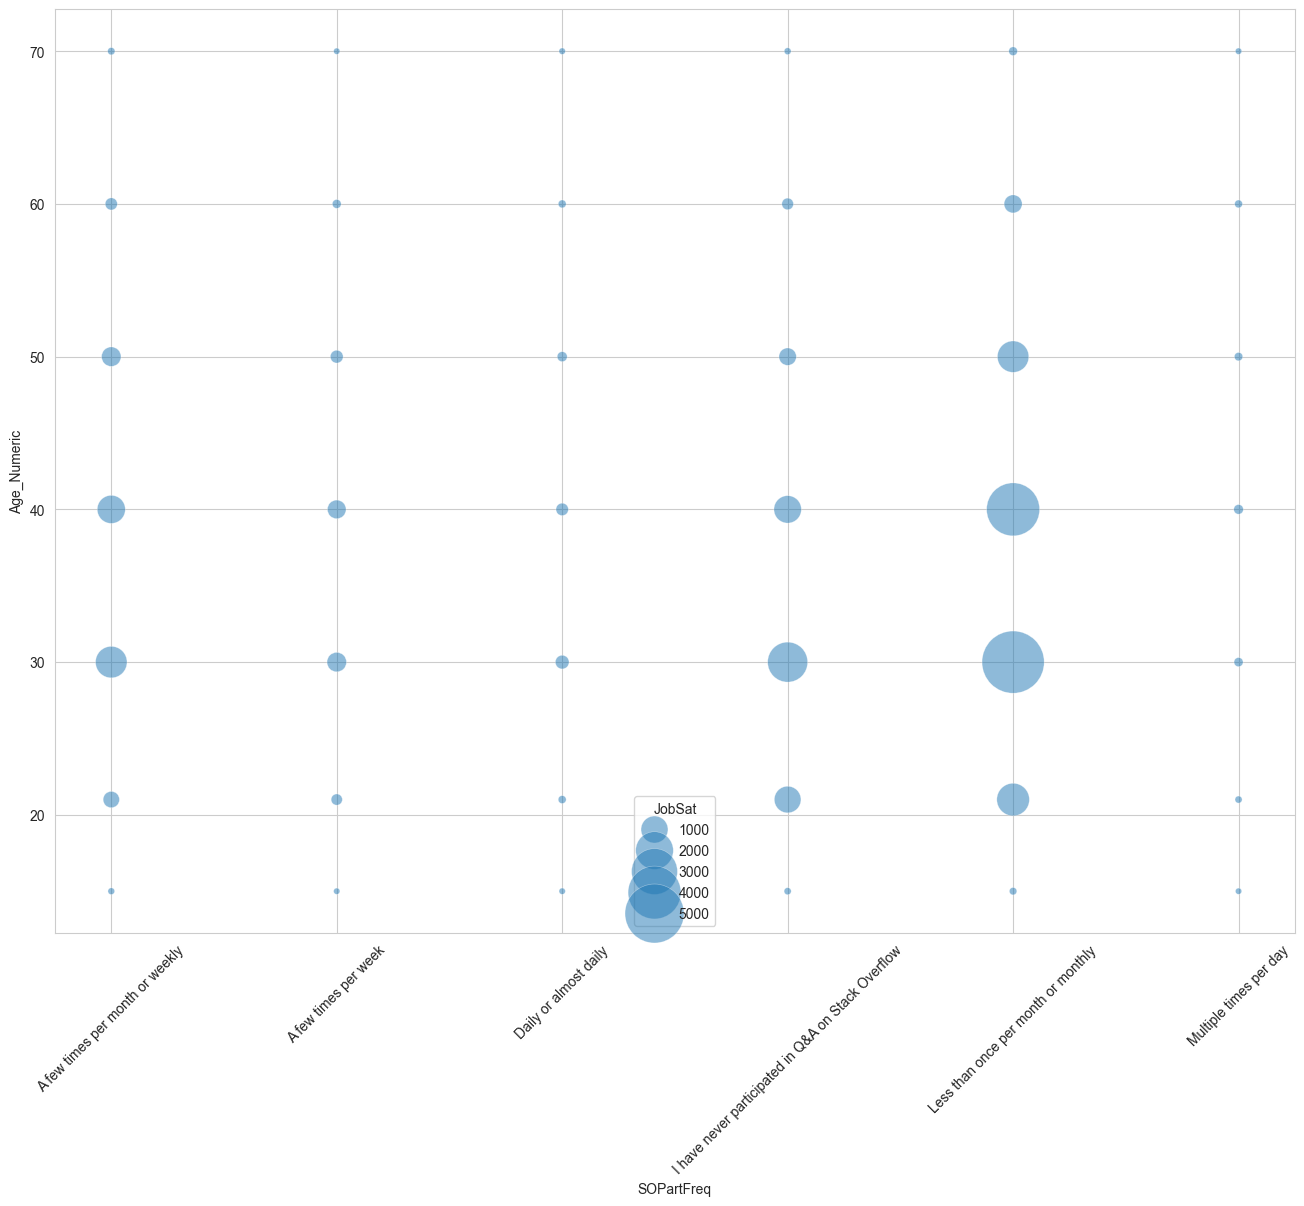

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))
# Map 'size' to the count we just calculated
sns.scatterplot(data=df_bubble, y='Age_Numeric', x='SOPartFreq', size='JobSat', sizes=(20, 2000), alpha=0.5)
plt.xticks(rotation=45)
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [9]:
df_clean1 = df[['Age_Numeric', 'JobSat', 'ConvertedCompYearly']].dropna()

In [10]:
##Write your code here
# Grouping by Compensation and Satisfaction, calculating the average Age for bubble size
# Grouping by both axes and calculating mean Age as a new DataFrame column
df_bubble = df_clean1.groupby(['ConvertedCompYearly', 'JobSat'], as_index=False)['Age_Numeric'].mean()
df_bubble

,ConvertedCompYearly,JobSat,Age_Numeric
0,1.0,1.0,40.000000
1,1.0,4.0,40.000000
2,1.0,5.0,30.500000
3,1.0,6.0,36.666667
4,1.0,7.0,40.000000
...,...,...,...
8786,3367716.0,7.0,30.000000
8787,4936778.0,7.0,30.000000
8788,6340564.0,6.0,40.000000
8789,9000000.0,10.0,21.000000


In [11]:
df['ConvertedCompYearly']

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
         ...  
65452      NaN
65453      NaN
65454    997.0
65455      NaN
65456      NaN
Name: ConvertedCompYearly, Length: 65457, dtype: float64

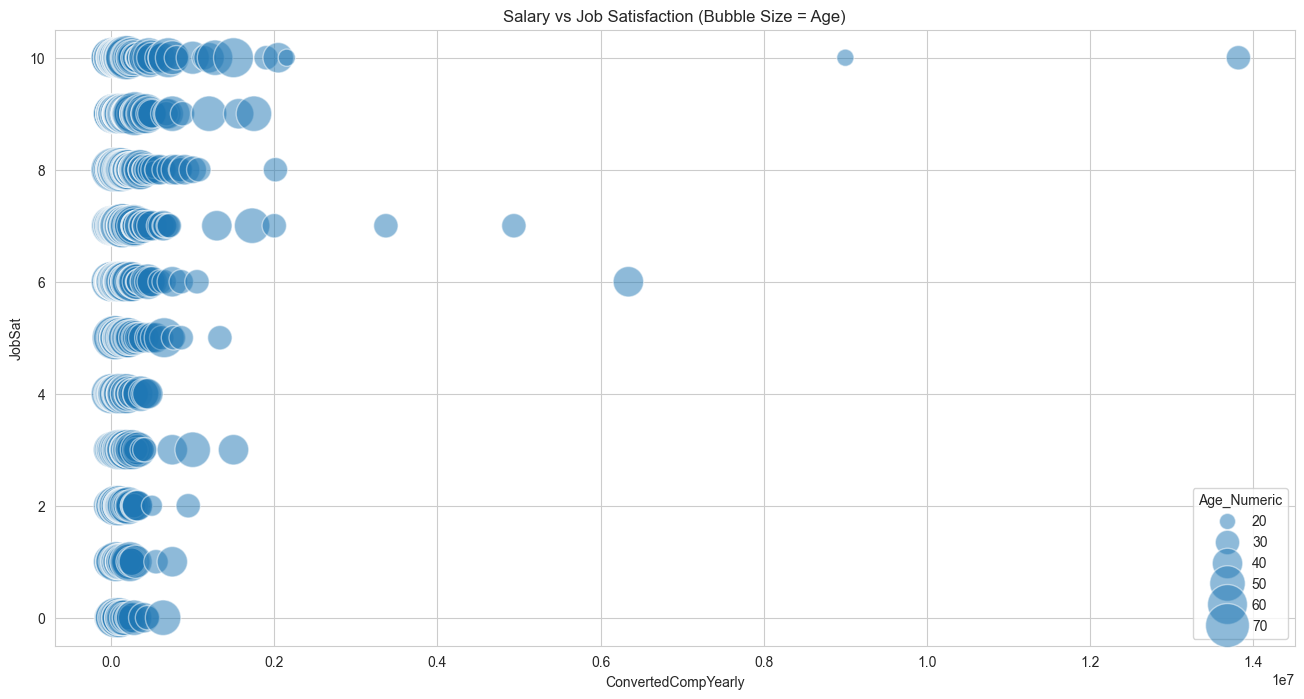

In [12]:
plt.figure(figsize=(16, 8))
# 'size' uses the mean age we calculated; 'sizes' sets the range of bubble diameters
sns.scatterplot(data=df_bubble, x='ConvertedCompYearly', y='JobSat', size='Age_Numeric', sizes=(50, 1000), alpha=0.5)

plt.title('Salary vs Job Satisfaction (Bubble Size = Age)')
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [13]:
# 1. Ensure we only use the columns we need
df_sub = df[['LanguageHaveWorkedWith', 'Age_Numeric']].dropna()

# 2. Split strings into lists
df_sub['Language'] = df_sub['LanguageHaveWorkedWith'].str.split(';')

# 3. Transform each language into its own row
df_expanded = df_sub.explode('Language')

# 4. Group to find the frequency (count) per language per age
df_bubble = df_expanded.groupby(['Language', 'Age_Numeric'], as_index=False).size()
df_bubble = df_expanded.groupby(['Language','Age_Numeric']), as_index = False).size()
df_bubble = df_bubble.rename(columns={'size': 'Frequency'})


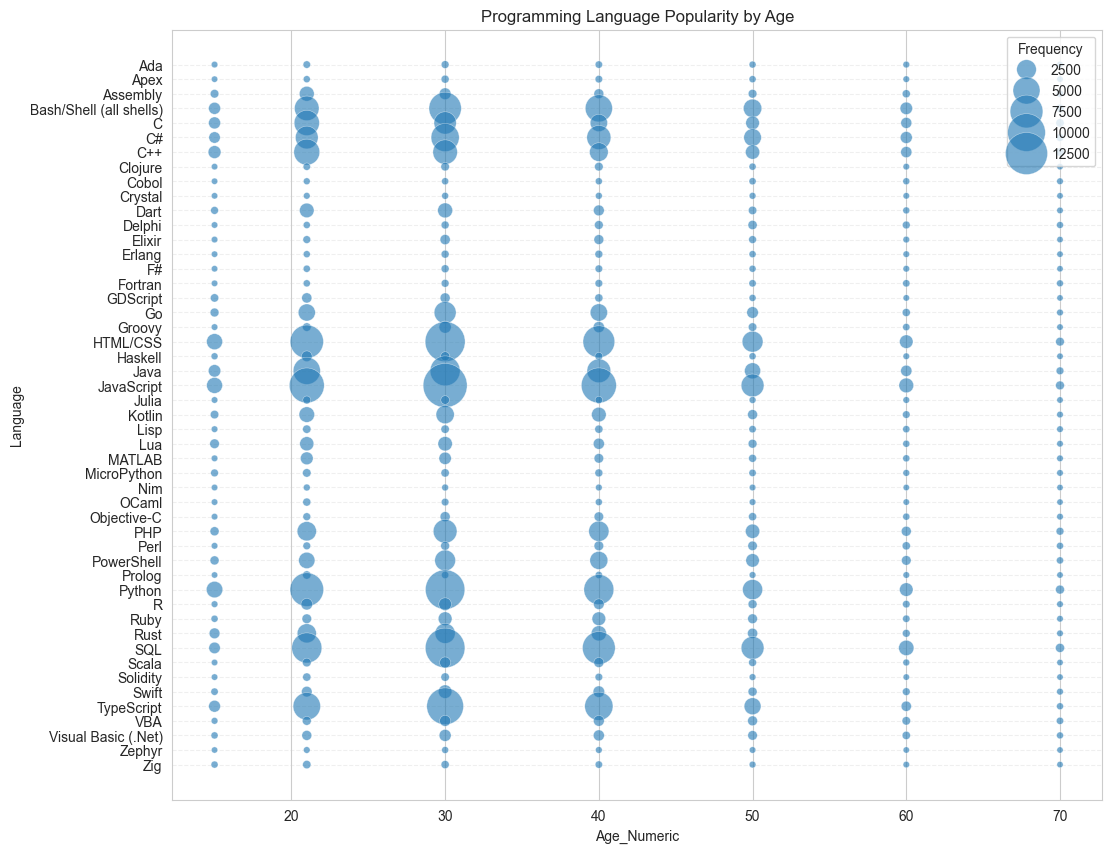

In [14]:
plt.figure(figsize=(12, 10))

# Plotting Language vs Age with Frequency as the bubble size
sns.scatterplot(data=df_bubble,
                x='Age_Numeric',
                y='Language',
                size='Frequency',
                sizes=(20, 1000),
                alpha=0.6)

plt.title('Programming Language Popularity by Age')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [15]:
# 1. Subset and clean
df_sub = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()

# 2. Split and Explode
df_sub['Database'] = df_sub['DatabaseWantToWorkWith'].str.split(';')
df_exploded = df_sub.explode('Database')

# 3. Group and Count (using your preferred syntax)
df_bubble = df_exploded.groupby(['Database', 'JobSat'])['Database'].count().reset_index(name='RespondentCount')


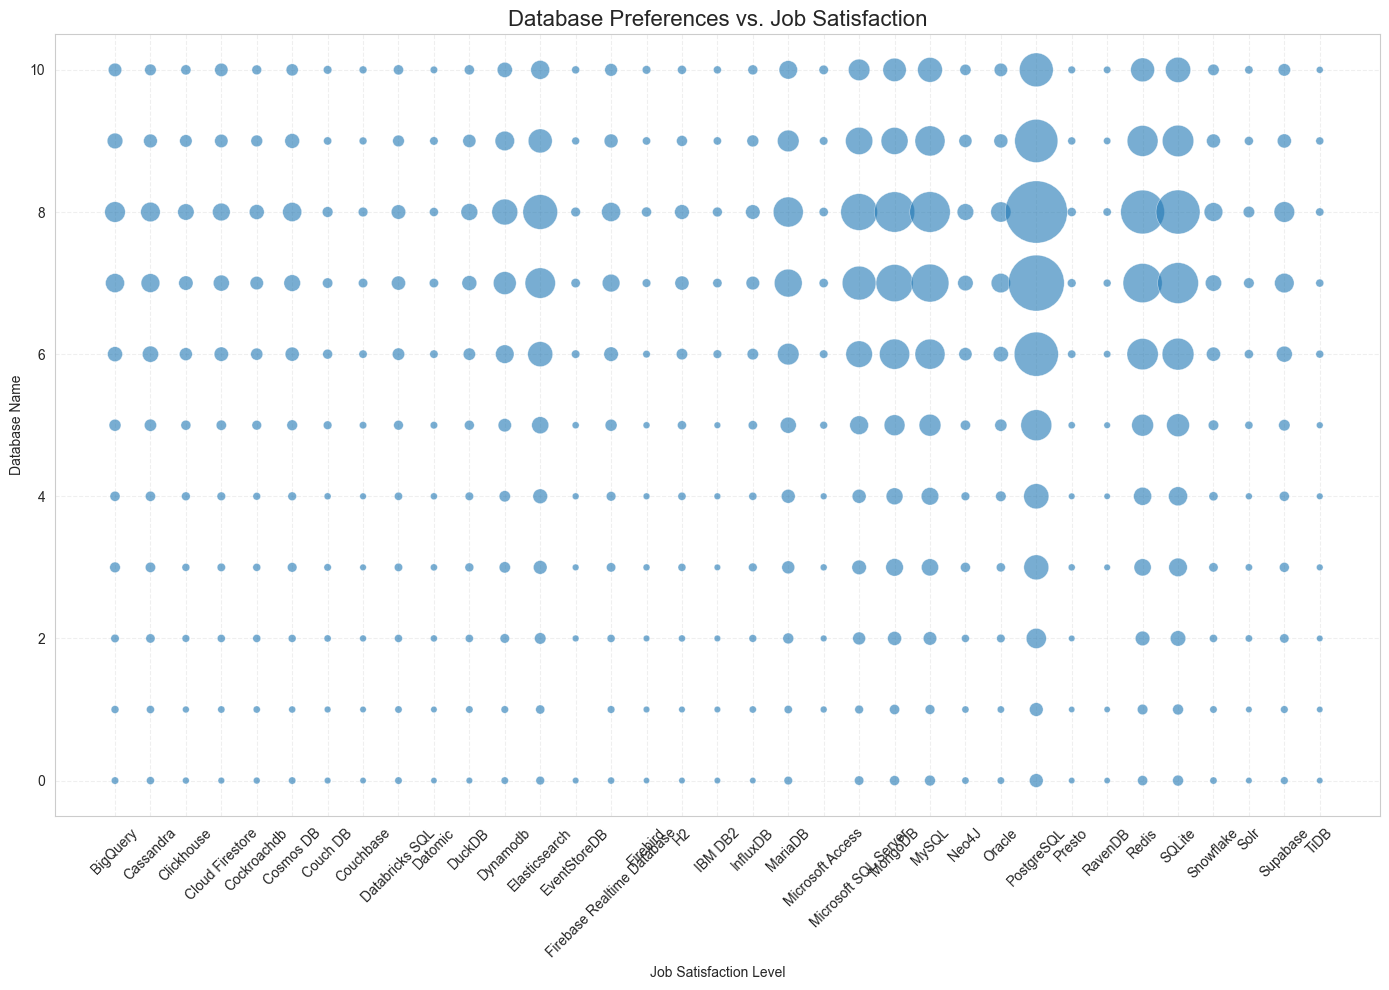

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# Create the bubble plot
sns.scatterplot(data=df_bubble,
                x='Database',
                y='JobSat',

                size='RespondentCount',
                sizes=(20, 2000),
                alpha=0.6,
                legend=False)

plt.title('Database Preferences vs. Job Satisfaction', fontsize=16)
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Database Name')
plt.xticks(rotation=45) # Rotates labels for better readability
plt.grid(axis='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


In [17]:
##Write your code here
df['DevType'].unique()

<StringArray>
[                                            nan,
                         'Developer, full-stack',
                          'Developer Experience',
                                       'Student',
                           'Academic researcher',
                               'Project manager',
                            'Developer Advocate',
                           'Developer, back-end',
                       'Other (please specify):',
                          'Developer, front-end',
                        'Database administrator',
 'Developer, desktop or enterprise applications',
                 'Cloud infrastructure engineer',
 'Data scientist or machine learning specialist',
                   'Research & Development role',
   'Developer, embedded applications or devices',
                          'System administrator',
                             'DevOps specialist',
                           'Engineering manager',
                                    

In [37]:
# Select columns and drop rows with missing values
df_sub = df[['DevType', 'ConvertedCompYearly', 'JobSat']].dropna()
df_sub = df_sub[df_sub['ConvertedCompYearly']<=df_sub['ConvertedCompYearly'].quantile(0.99)]

In [38]:
# 1. Create a new column with the split lists
df_sub['Roles'] = df_sub['DevType'].str.split(';')

# 2. Expand the lists into individual rows
df_exploded = df_sub.explode('Roles')


In [39]:
df_sub['Roles']
# df_exploded

72       [Data scientist or machine learning specialist]
379      [Data scientist or machine learning specialist]
389                                            [Student]
392                                [Engineering manager]
398                              [Developer, full-stack]
                              ...                       
41184                                  [Project manager]
41186                            [Developer, full-stack]
41187      [Developer, embedded applications or devices]
65447                              [Developer, back-end]
65454                              [Academic researcher]
Name: Roles, Length: 15900, dtype: object

In [40]:
# Grouping by Roles and JobSat to get the average Compensation
df_bubble = df_exploded.groupby(['Roles', 'JobSat'], as_index=False)['ConvertedCompYearly'].mean().rename(columns={'ConvertedCompYearly': 'Meanconvertedcomp'})
# df_buble = df_exploded.groupby(['Roles','JobSat']), as_index=False)['ConvertedCompyearly'].mean()

In [41]:
df_bubble

,Roles,JobSat,Meanconvertedcomp
0,Academic researcher,1.0,42366.500000
1,Academic researcher,2.0,40765.333333
2,Academic researcher,3.0,42838.714286
3,Academic researcher,4.0,38840.300000
4,Academic researcher,5.0,54566.947368
...,...,...,...
329,System administrator,6.0,59243.000000
330,System administrator,7.0,61521.125000
331,System administrator,8.0,59162.933333
332,System administrator,9.0,86339.375000


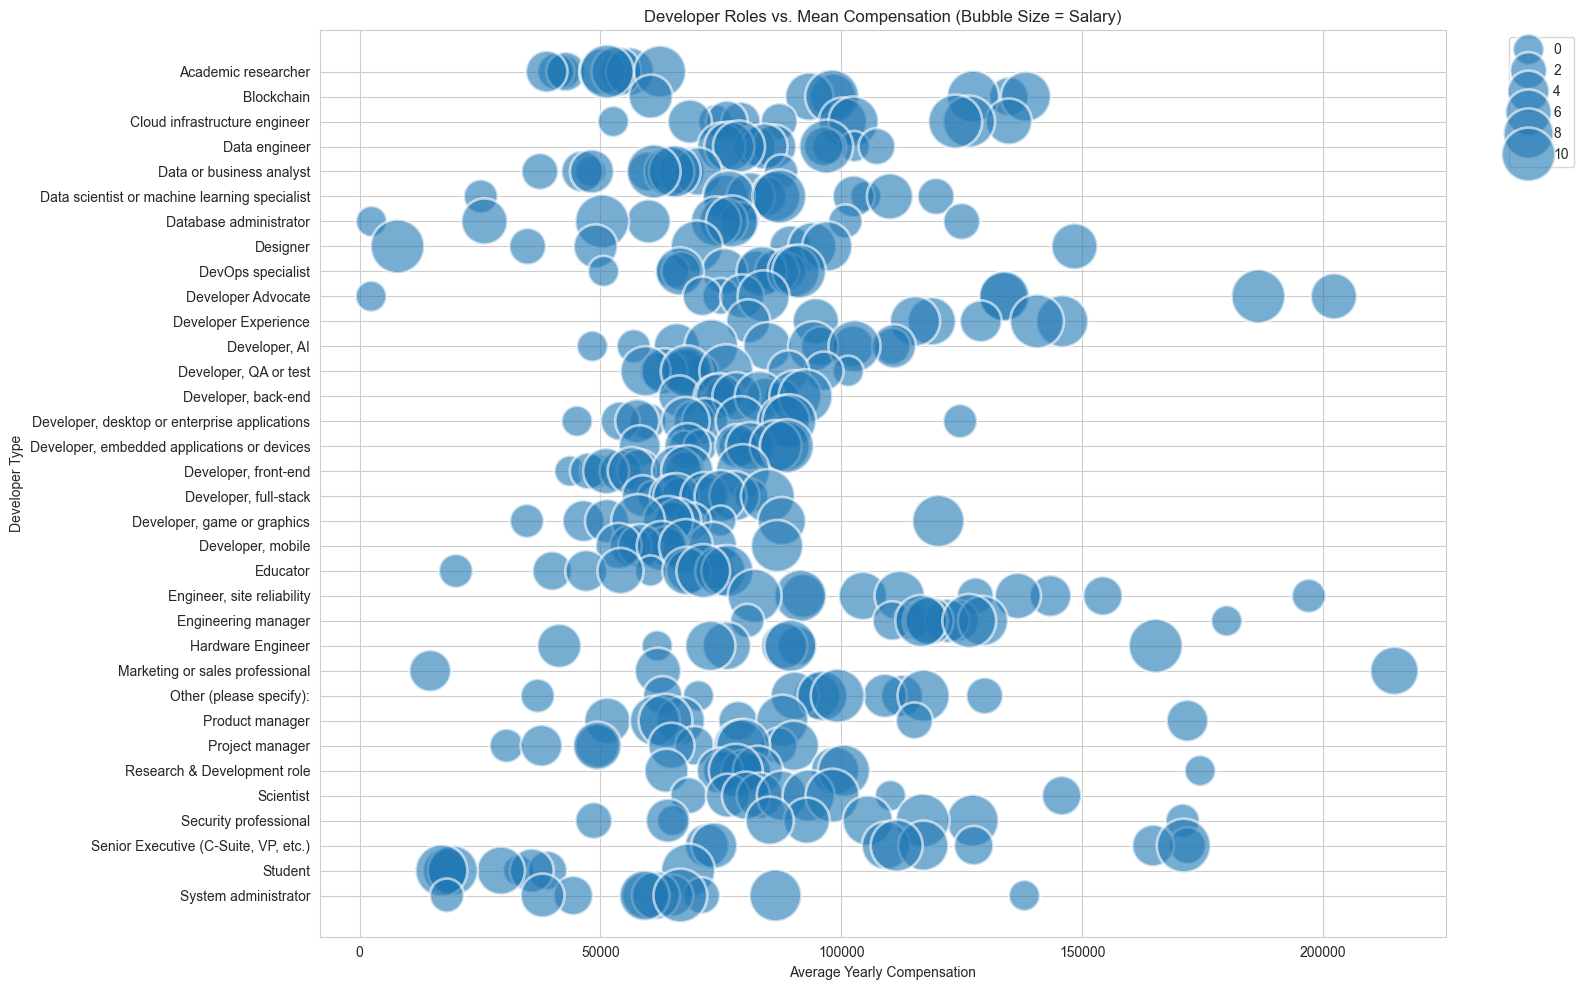

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

# Using the mean salary for both the X-axis and the size of the bubbles
sns.scatterplot(data=df_bubble,
                x='Meanconvertedcomp',
                y='Roles',
                # hue='',
                size='JobSat',
                sizes=(500, 1500),
                alpha=0.6)

plt.title('Developer Roles vs. Mean Compensation (Bubble Size = Salary)')
plt.xlabel('Average Yearly Compensation')
plt.ylabel('Developer Type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside

plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


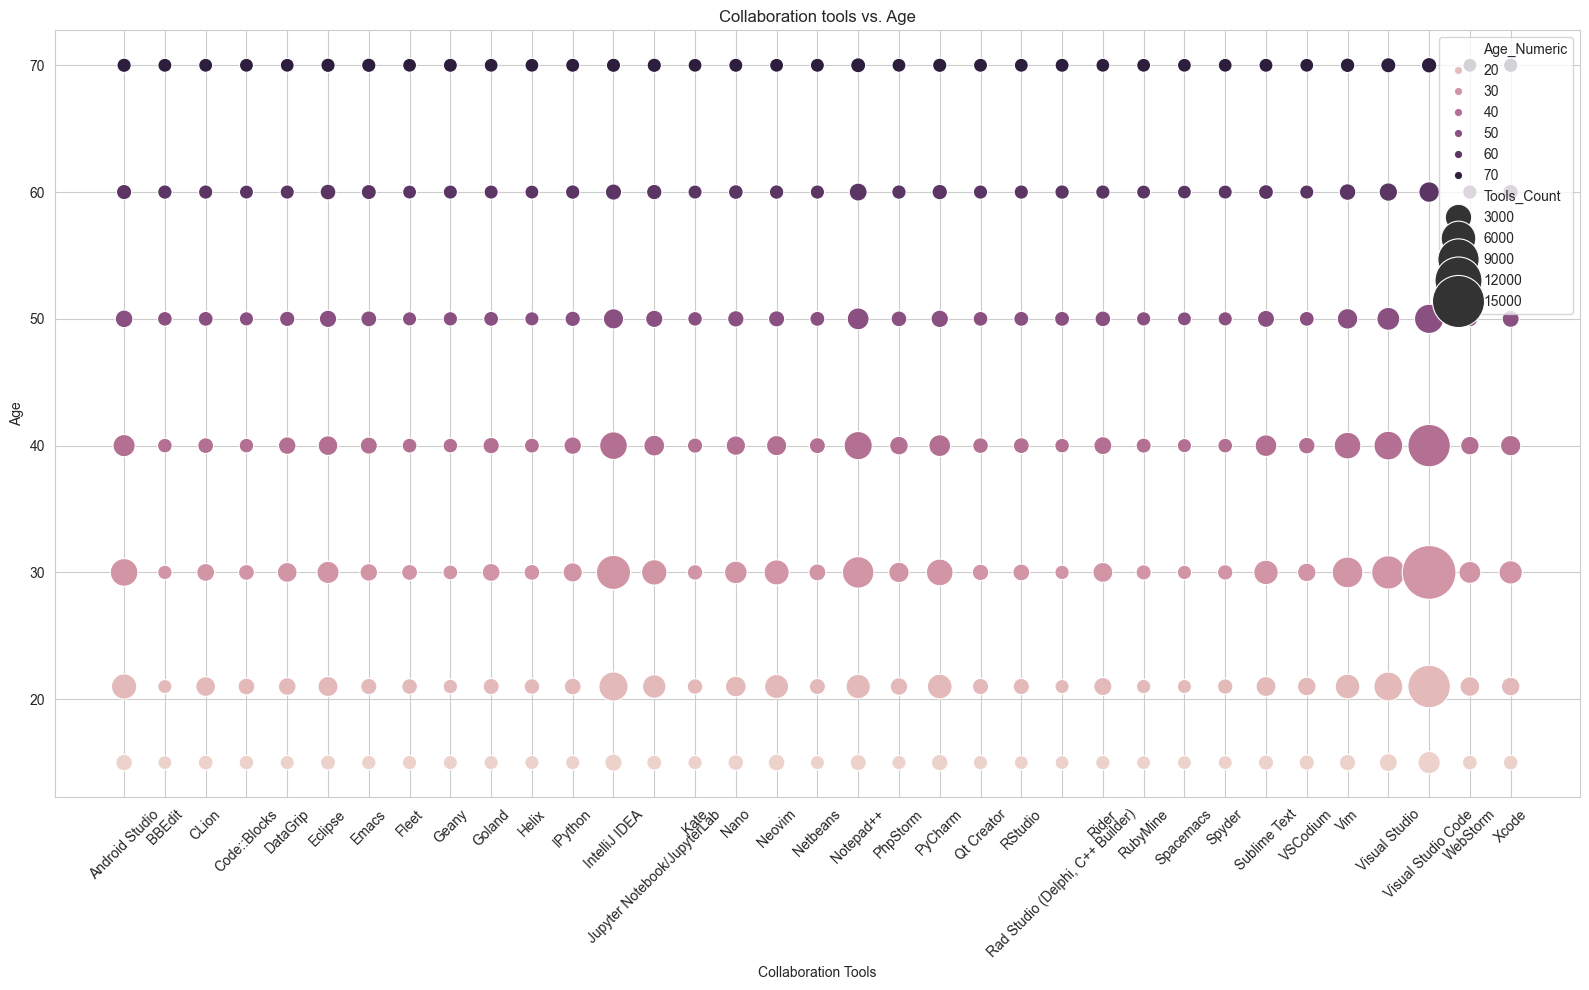

In [54]:
df_sub1 = df[['NEWCollabToolsHaveWorkedWith', 'Age_Numeric']].dropna()
df_sub1['tools'] = df_sub1['NEWCollabToolsHaveWorkedWith'].str.split(';')
df_sub1 = df_sub1.explode('tools')
df_bubble2 = df_sub1.groupby(['tools', 'Age_Numeric'], as_index=False).size()
df_bubble2 = df_bubble2.rename(columns={'size':'Tools_Count'})
plt.figure(figsize=(16, 10))
sns.scatterplot(data = df_bubble2, x = 'tools', y = 'Age_Numeric', size = 'Tools_Count', sizes = (100,1500), hue = 'Age_Numeric')

plt.title('Collaboration tools vs. Age')
plt.xlabel('Collaboration Tools')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
##Write your code here
df['NEWCollabToolsHaveWorkedWith'].unique()

<StringArray>
[                                                                                                                      nan,
                                                                                     'PyCharm;Visual Studio Code;WebStorm',
                                                                                                           'Visual Studio',
                                                                                                                     'Vim',
                                                                                       'Nano;Vim;Visual Studio Code;Xcode',
                                                                                                                 'RStudio',
                                                                                                      'Visual Studio Code',
                  'Android Studio;IntelliJ IDEA;Netbeans;Notepad++;Sublime Text;Visual Studio;Visual Studio Code;WebSt

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



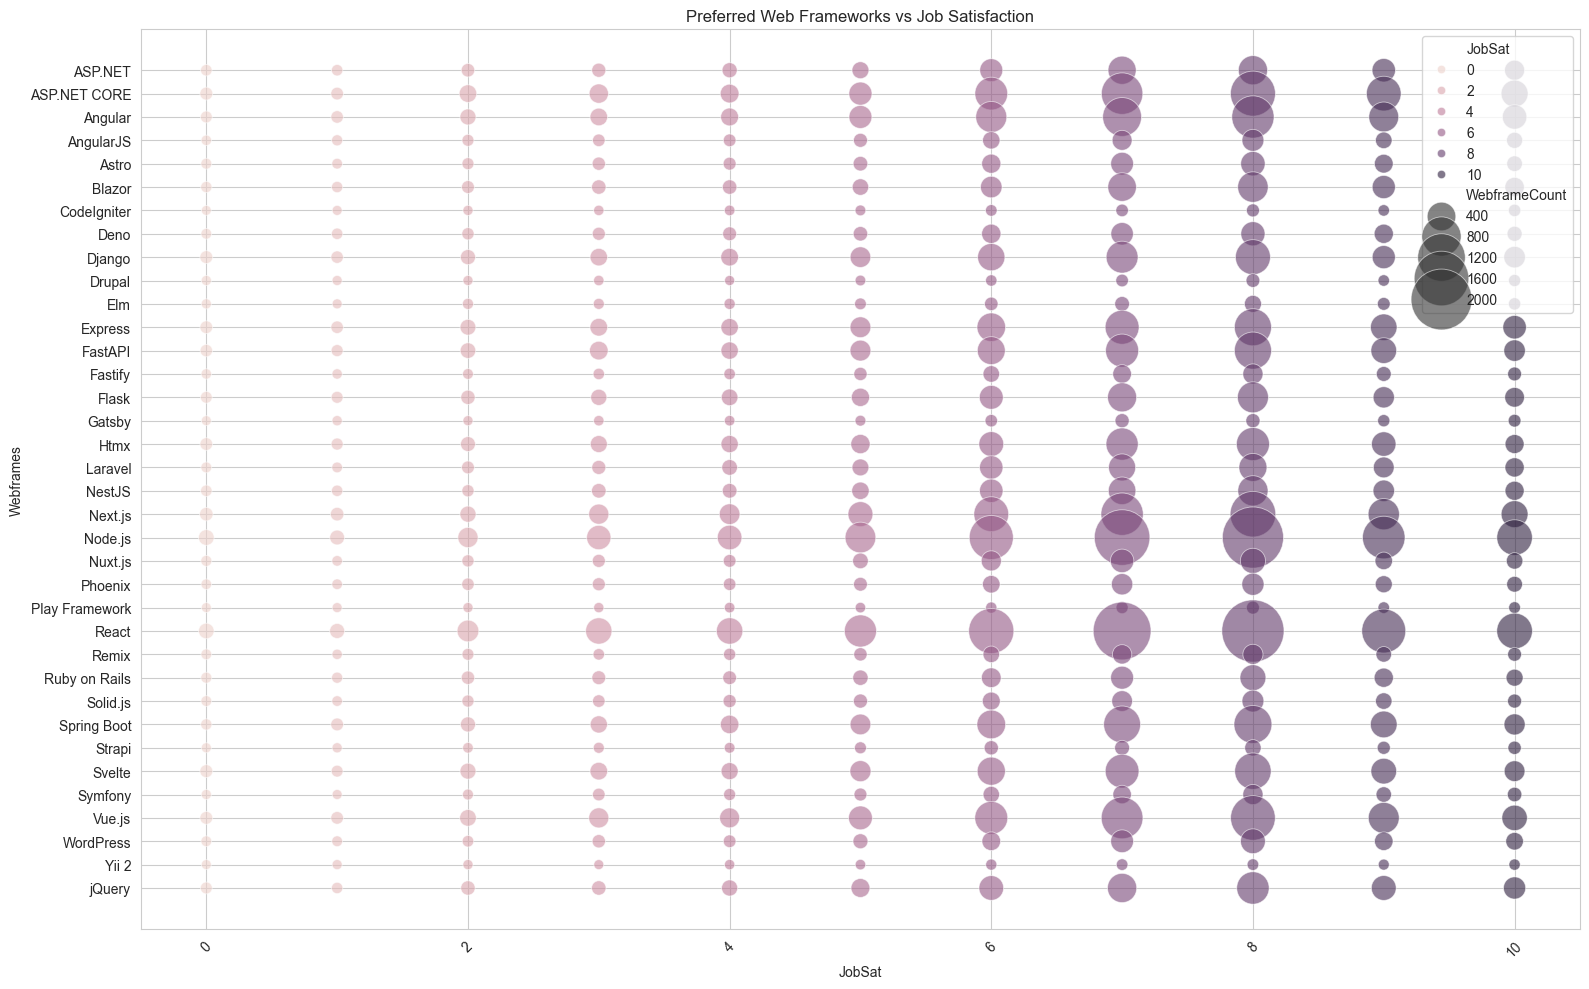

In [62]:
# 1. Subset (Case-sensitive names check karein)
df_subset = df[['WebframeWantToWorkWith', 'JobSat']].dropna()

# 2. Split and Explode
df_subset['Webframes'] = df_subset['WebframeWantToWorkWith'].str.split(';')
df_exploded = df_subset.explode('Webframes')

# 3. Group and Count (Old Way syntax)
df_bubble = df_exploded.groupby(['Webframes', 'JobSat'])['Webframes'].count().reset_index(name='WebframeCount')

# 4. Plotting
plt.figure(figsize=(16, 10))
sns.scatterplot(data=df_bubble,
                x='JobSat',
                y='Webframes',
                size='WebframeCount',
                sizes=(50, 2000),
                hue='JobSat',
                alpha=0.6)

plt.title('Preferred Web Frameworks vs Job Satisfaction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
##Write your code here

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [4]:
top_countries = df['Country'].value_counts().nlargest(5).index
top_countries

Index(['United States of America', 'Germany', 'India',
       'United Kingdom of Great Britain and Northern Ireland', 'Ukraine'],
      dtype='str', name='Country')

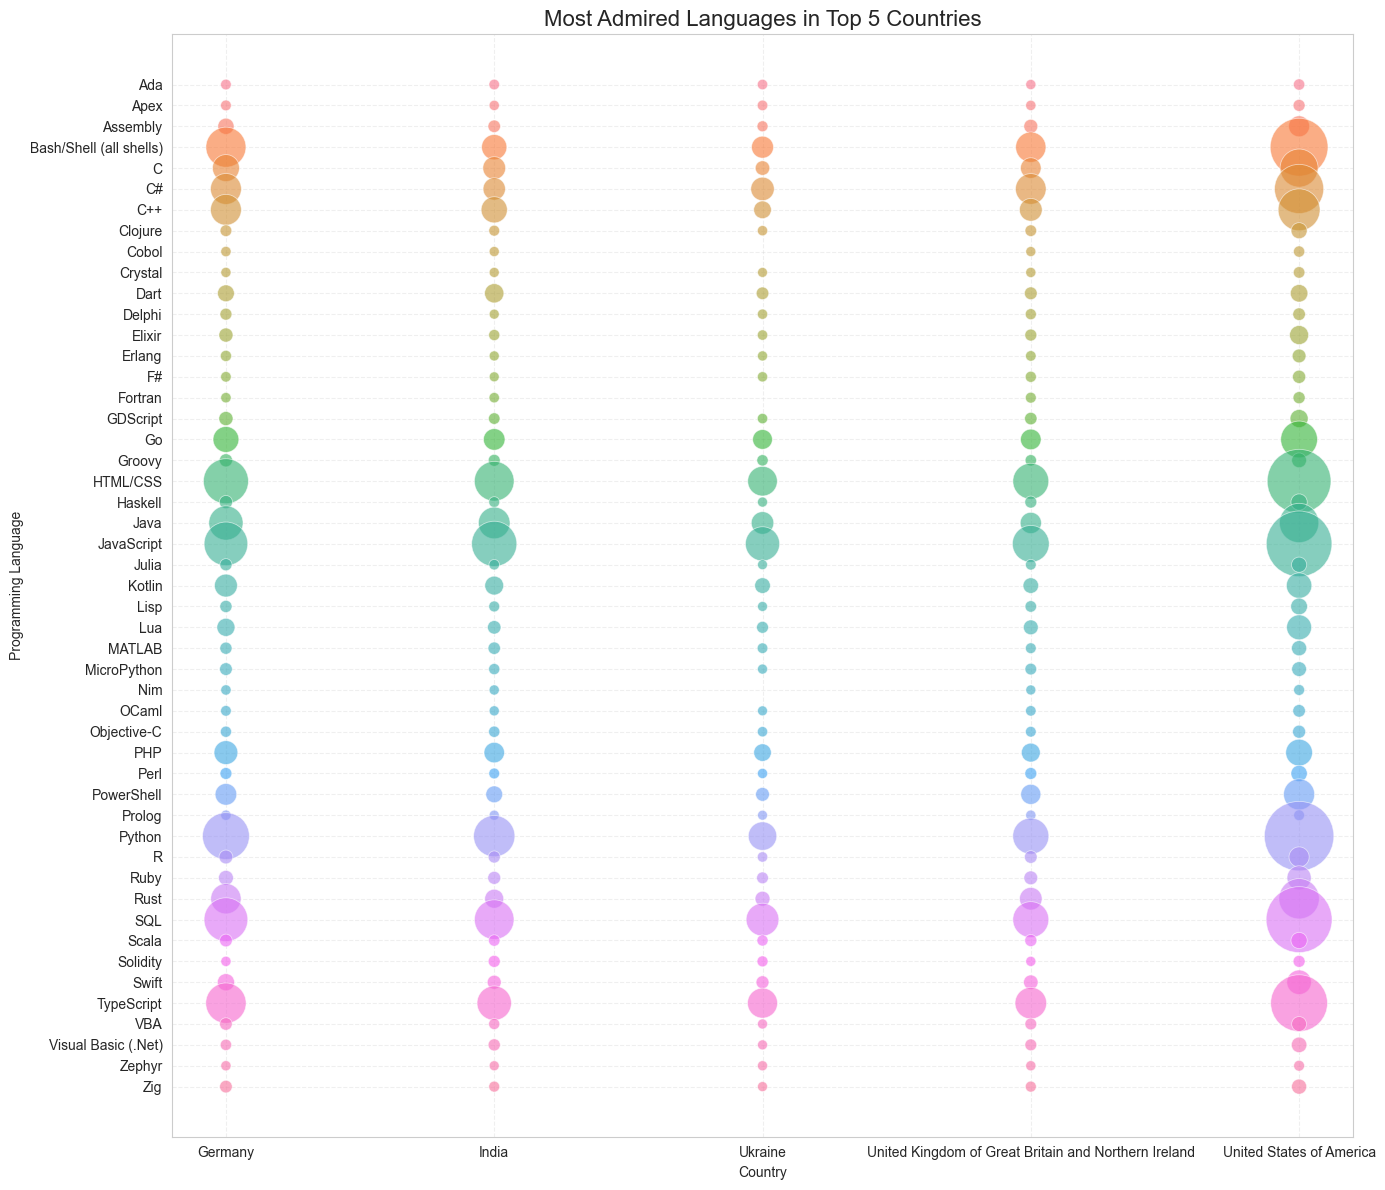

In [64]:
##Write your code here
# Select columns and drop empty values
df_sub = df[['LanguageAdmired', 'Country']].dropna()

# Split the string and expand into individual rows
df_sub['Language'] = df_sub['LanguageAdmired'].str.split(';')
df_exploded = df_sub.explode('Language')
 # Group by Country and Language to get the "bubble size"
df_bubble = df_exploded.groupby(['Country', 'Language'])['Language'].count().reset_index(name='Frequency')
# Get names of the top 5 countries with the most respondents
top_countries = df['Country'].value_counts().nlargest(5).index

# Filter the bubble data for only these countries
df_plot = df_bubble[df_bubble['Country'].isin(top_countries)]
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

# x = Country, y = Language, size = Frequency (How many people admire it)
sns.scatterplot(data=df_plot,
                x='Country',
                y='Language',
                size='Frequency',
                hue='Language',
                sizes=(50, 2500),
                alpha=0.6,
                legend=False)

plt.title('Most Admired Languages in Top 5 Countries', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Programming Language')
plt.grid(axis='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
